In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

In [2]:
shovel = "Shovel"
cube = "Cube"

c_0 = "C0"
c_1 = "C1"
c_2 = "C2"
p_0 = "P0"
p_1 = "P1"
p_2 = "P2"

conditions = [c_0, c_1, c_2, p_0, p_1, p_2]

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']

In [3]:
condition = "Condition"
task = "Task"

borg_cr = "How physically challenging was the experience?"
sp_fatigue = "How fatigued where you after the experience?"

general_weight_perception = "I felt the weight of the object, while i was grabbing it"
general_weight_realism = "The weight of the object, while i was grabbing it, felt realistic"
general_custom = [general_weight_perception, general_weight_realism]

shovel_load_weight = "I felt the weight of the shovel increasing when loading it"
shovel_unload_weight = "I felt the weight of the shovel decreasing when unloading it"
shovel_load_effort = "After the shovel had been loaded, it required more effort to manipulate"
shovel_unload_effort = "After the shovel had been unloaded, it required less effort to manipulate"
shovel_custom = [shovel_load_weight, shovel_unload_weight, shovel_load_effort, shovel_unload_effort]

fps_1 = "  My sense of being in the virtual world was like being in a real place."
fps_2 = "During the experience, I felt the virtual world was reality for me. "
fps_3 = "I felt like I was actually there in the virtual world. "
fps_4 = "I felt present in the virtual world. "
fps_5 = "I felt I could control my actions within the virtual world. "
fps_6 = "I felt the virtual world was responsive to my actions. "
fps_7 = "I felt I could move or manipulate objects easily in the virtual world. "
fps_8 = "I felt involved in the virtual world experience. "
fps_9 = "I could concentrate on the virtual activities rather than the controls to perform them. "
fps_10 = "When something happened to my virtual body, I felt it happened to my real body. "
#Interaction Presence Score: (FPS-1 + FPS-2 + FPS-4 + FPS-5 + FPS-6 + FPS-7 + FPS-8 + FPS-9) / 8
fps_interaction = [fps_1, fps_2, fps_4, fps_5, fps_6, fps_7, fps_8, fps_9]
#Scenario Presence Score: (FPS-3 + FPS-4 + FPS-8) / 3
fps_scenario = [fps_3, fps_4, fps_8]
#Display Presence Score: (FPS-1 + FPS-2 + FPS-3 + FPS-4 +FPS-7 +FPS-8 + FPS-10) / 7
fps_display = [fps_1, fps_2, fps_3, fps_4, fps_7, fps_8, fps_10]
#Total Presence Score: (FPS1-10) / 10
fps_total = [fps_1, fps_2, fps_3, fps_4, fps_5, fps_6, fps_7, fps_8, fps_9, fps_10]

fps_custom = [fps_5, fps_6, fps_7, fps_9, fps_10]

relevant_keys = [condition, task, borg_cr, sp_fatigue] + general_custom + shovel_custom + fps_total

In [4]:
def get_df(name):
    path = './questionnaires/' + name + '.csv'
    return pd.read_csv(path)

In [5]:
data = get_df('experiments').filter(items=relevant_keys)

data.head(3)

,Condition,Task,How physically challenging was the experience?,How fatigued where you after the experience?,"I felt the weight of the object, while i was grabbing it","The weight of the object, while i was grabbing it, felt realistic",I felt the weight of the shovel increasing when loading it,I felt the weight of the shovel decreasing when unloading it,"After the shovel had been loaded, it required more effort to manipulate","After the shovel had been unloaded, it required less effort to manipulate",My sense of being in the virtual world was like being in a real place.,"During the experience, I felt the virtual world was reality for me.",I felt like I was actually there in the virtual world.,I felt present in the virtual world.,I felt I could control my actions within the virtual world.,I felt the virtual world was responsive to my actions.,I felt I could move or manipulate objects easily in the virtual world.,I felt involved in the virtual world experience.,I could concentrate on the virtual activities rather than the controls to perform them.,"When something happened to my virtual body, I felt it happened to my real body."
0,C0,Cube,1 - Very light,1 - Very alert and fully awake,4,4,NaN,NaN,NaN,NaN,6,4,3,4,6,7,6,6,7,6
1,C1,Cube,2 - Light,2 - Very energetic but no longer at one’s peak,4,4,NaN,NaN,NaN,NaN,4,3,3,3,6,7,5,4,5,4
2,C2,Cube,1 - Very light,1 - Very alert and fully awake,3,3,NaN,NaN,NaN,NaN,5,5,4,5,6,5,5,5,5,4


In [6]:
def plot_experiments(cube_values, shovel_values, title, ylabel):
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))

    labels = conditions

    cube_means = list(map(lambda x: np.mean(x), cube_values))
    axs[0,0].bar(labels, cube_means, color=colors)
    axs[0,0].set_title('[Cube] Mean' + title)
    axs[0,0].set_ylabel(ylabel)

    axs[1,0].boxplot(cube_values, tick_labels=labels)
    axs[1,0].set_title('[Cube] ' + title)
    axs[1,0].set_ylabel(ylabel)

    shovel_means = list(map(lambda x: np.mean(x), shovel_values))
    axs[0,1].bar(labels, shovel_means, color=colors)
    axs[0,1].set_title('[Shovel] Mean' + title)
    axs[0,1].set_ylabel(ylabel)

    axs[1,1].boxplot(shovel_values, tick_labels=labels)
    axs[1,1].set_title('[Shovel] ' + title)
    axs[1,1].set_ylabel(ylabel)

    plt.show()

def column_weighted_sum(row, subset):
    column_values = list(map(lambda x: row[x], subset))
    return np.sum(column_values) / len(subset)

def filter_condition(df, e, c):
    experiment_rows = df[df[task] == e]
    condition_rows = experiment_rows[experiment_rows[condition] == c]
    return condition_rows

def get_fps_subset(df, e, c, subset):
    filtered = filter_condition(df, e, c)
    single_values = []
    
    for i in range(len(filtered.index)):
        single_values.append(column_weighted_sum(filtered.iloc[i], subset))

    return single_values

def get_single_str(df, e, c, key):
    filtered = filter_condition(df, e, c)
    str_values = filtered[key]
    values = list(map(lambda x: int(x.split()[0]), str_values))

    return values

def get_single(df, e, c, key):
    filtered = filter_condition(df, e, c)
    values = filtered[key]

    return values

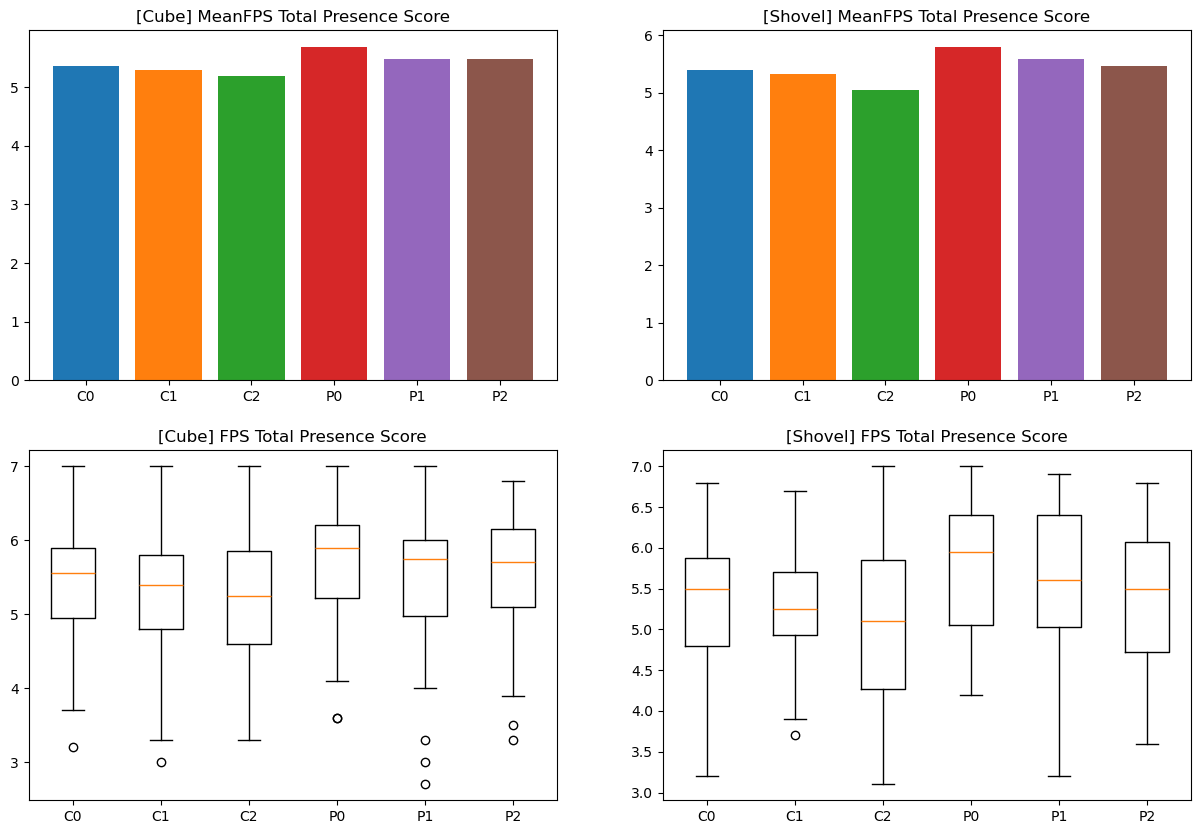

In [7]:
cube_values = list(map(lambda x: get_fps_subset(data, cube, x, fps_total), conditions))
shovel_values = list(map(lambda x: get_fps_subset(data, shovel, x, fps_total), conditions))

plot_experiments(
    cube_values= cube_values,
    shovel_values= shovel_values,
    title= 'FPS Total Presence Score',
    ylabel= ''
    )

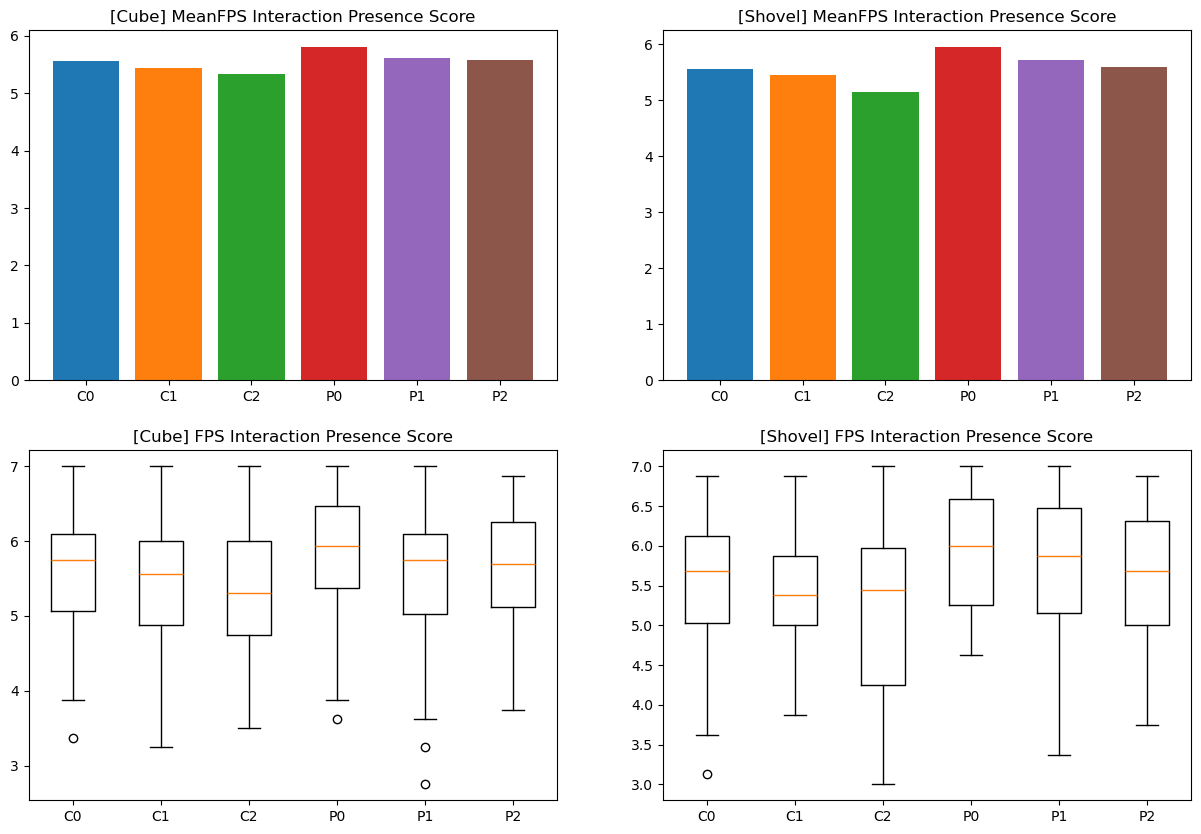

In [8]:
cube_values = list(map(lambda x: get_fps_subset(data, cube, x, fps_interaction), conditions))
shovel_values = list(map(lambda x: get_fps_subset(data, shovel, x, fps_interaction), conditions))

plot_experiments(
    cube_values= cube_values,
    shovel_values= shovel_values,
    title= 'FPS Interaction Presence Score',
    ylabel= ''
    )

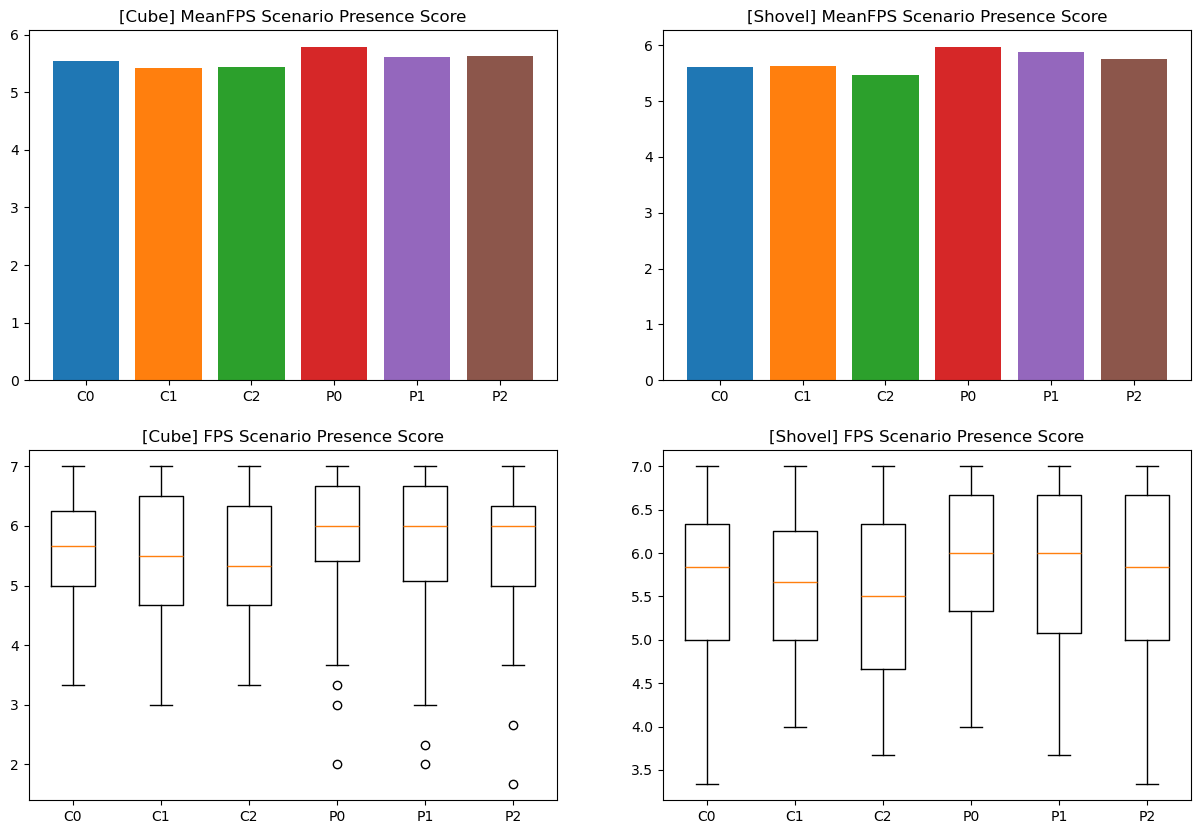

In [9]:
cube_values = list(map(lambda x: get_fps_subset(data, cube, x, fps_scenario), conditions))
shovel_values = list(map(lambda x: get_fps_subset(data, shovel, x, fps_scenario), conditions))

plot_experiments(
    cube_values= cube_values,
    shovel_values= shovel_values,
    title= 'FPS Scenario Presence Score',
    ylabel= ''
    )

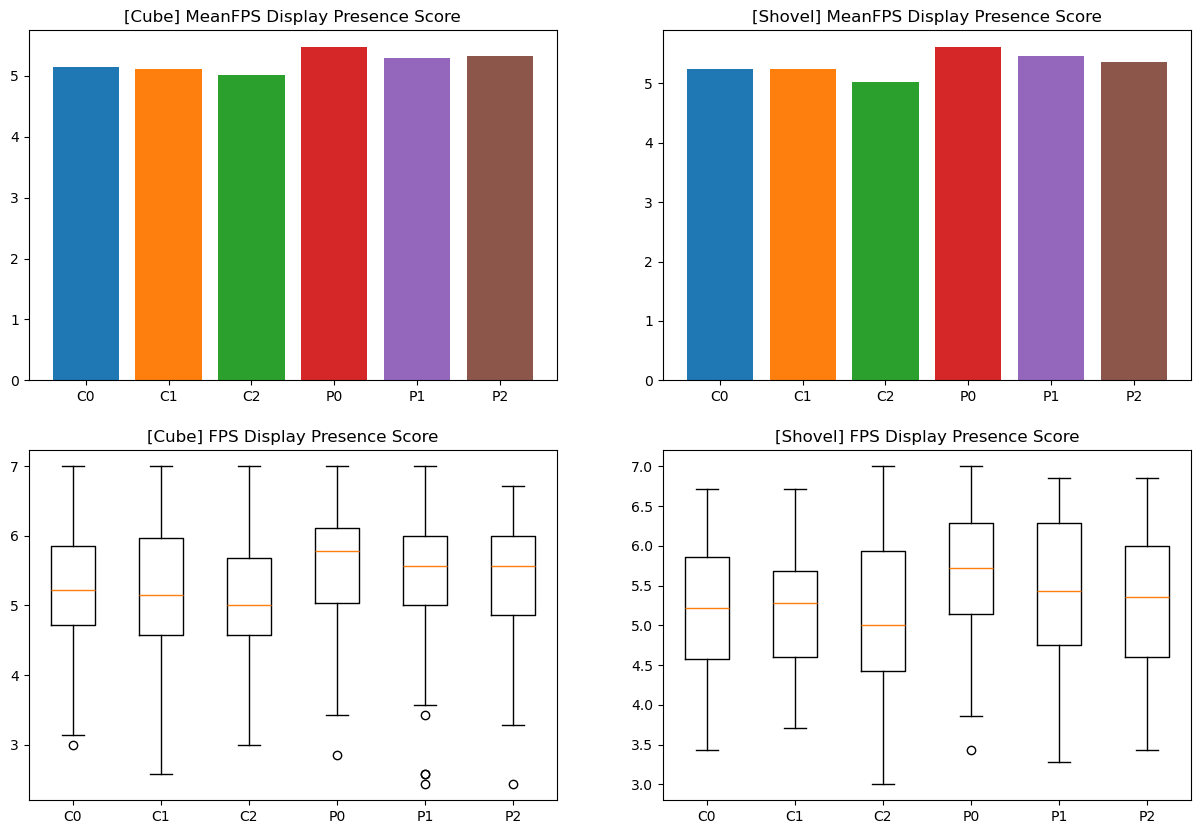

In [10]:
cube_values = list(map(lambda x: get_fps_subset(data, cube, x, fps_display), conditions))
shovel_values = list(map(lambda x: get_fps_subset(data, shovel, x, fps_display), conditions))

plot_experiments(
    cube_values= cube_values,
    shovel_values= shovel_values,
    title= 'FPS Display Presence Score',
    ylabel= ''
    )

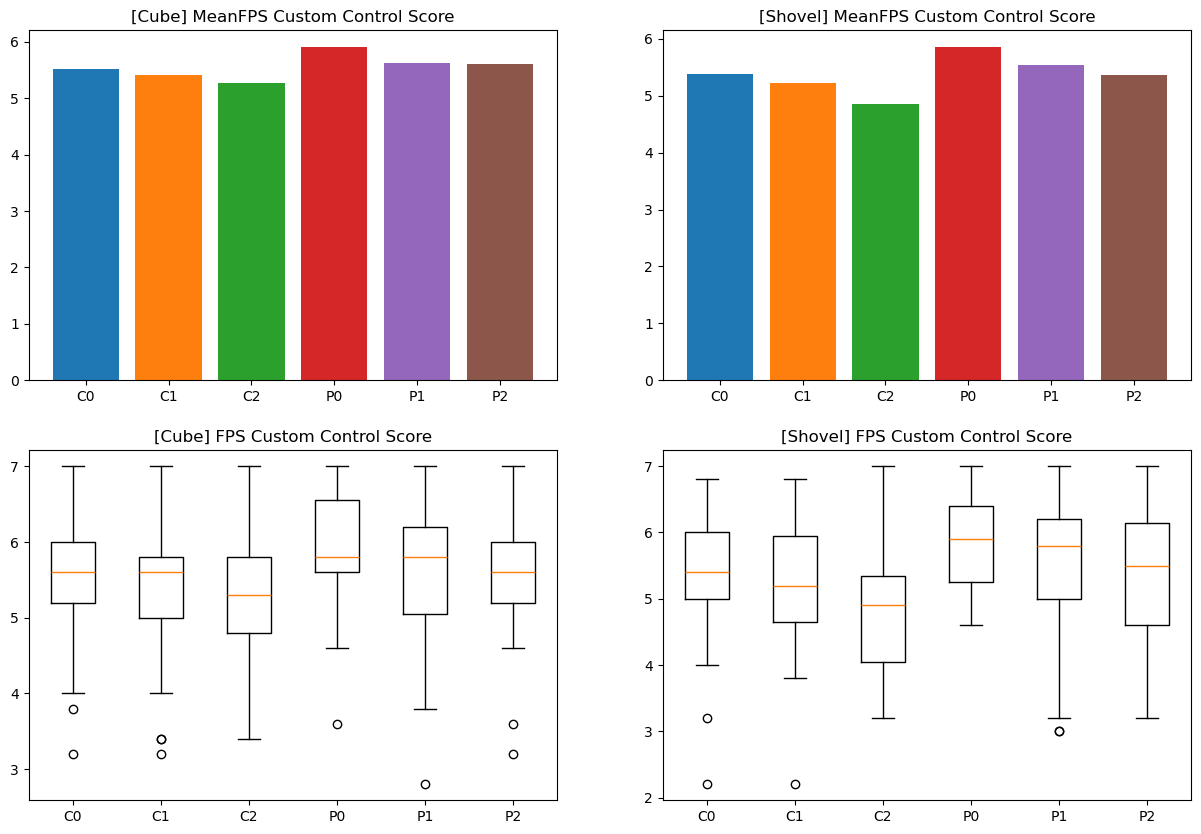

In [11]:
cube_values = list(map(lambda x: get_fps_subset(data, cube, x, fps_custom), conditions))
shovel_values = list(map(lambda x: get_fps_subset(data, shovel, x, fps_custom), conditions))

plot_experiments(
    cube_values= cube_values,
    shovel_values= shovel_values,
    title= 'FPS Custom Control Score',
    ylabel= ''
    )

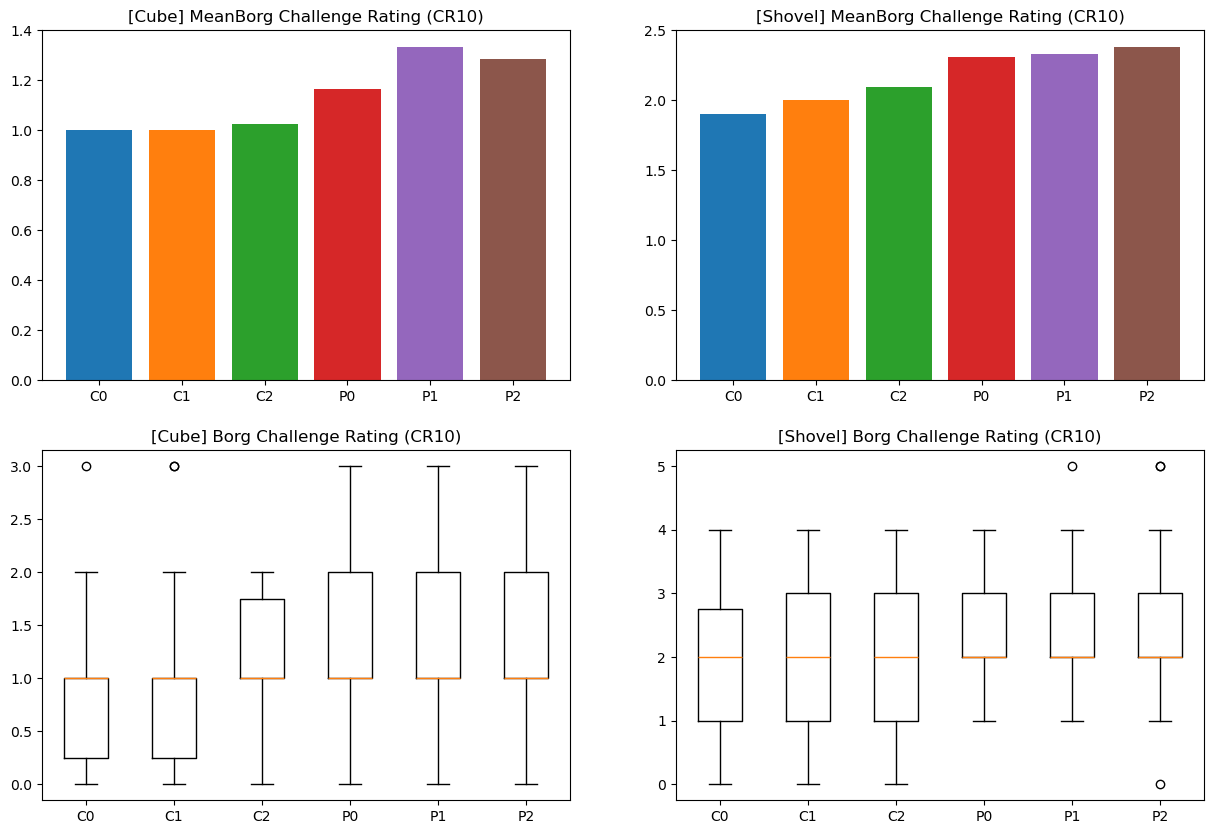

In [12]:
cube_values = list(map(lambda x: get_single_str(data, cube, x, borg_cr), conditions))
shovel_values = list(map(lambda x: get_single_str(data, shovel, x, borg_cr), conditions))

plot_experiments(
    cube_values= cube_values,
    shovel_values= shovel_values,
    title= 'Borg Challenge Rating (CR10)',
    ylabel= ''
    )

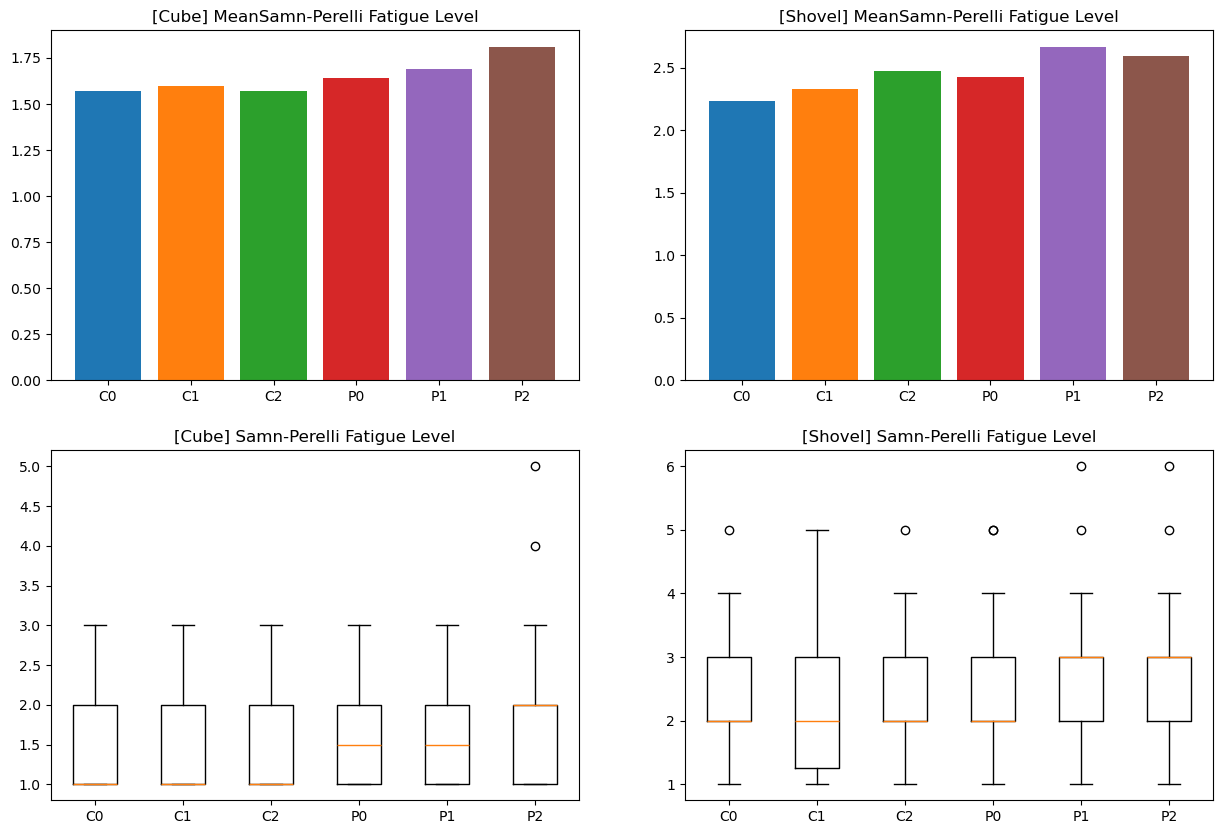

In [13]:
cube_values = list(map(lambda x: get_single_str(data, cube, x, sp_fatigue), conditions))
shovel_values = list(map(lambda x: get_single_str(data, shovel, x, sp_fatigue), conditions))

plot_experiments(
    cube_values= cube_values,
    shovel_values= shovel_values,
    title= 'Samn-Perelli Fatigue Level',
    ylabel= ''
    )

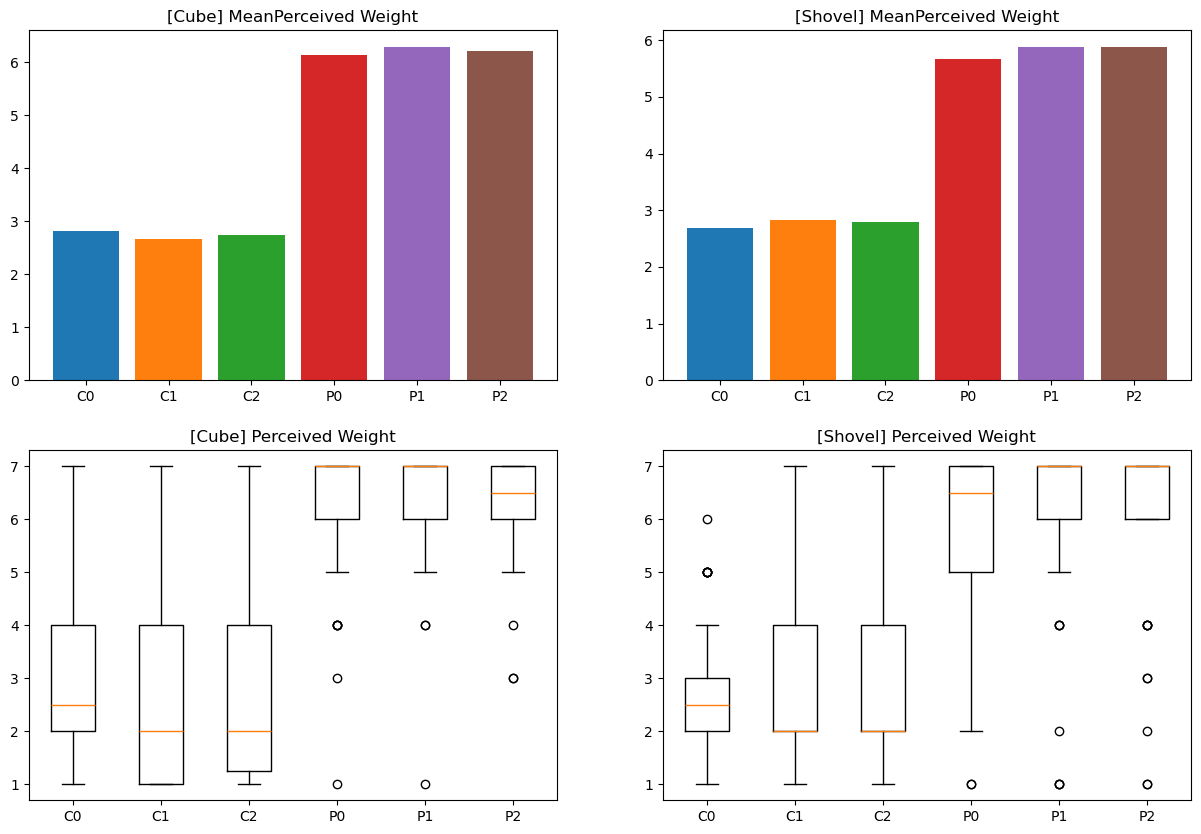

In [14]:
cube_values = list(map(lambda x: get_single(data, cube, x, general_weight_perception), conditions))
shovel_values = list(map(lambda x: get_single(data, shovel, x, general_weight_perception), conditions))

plot_experiments(
    cube_values= cube_values,
    shovel_values= shovel_values,
    title= 'Perceived Weight',
    ylabel= ''
    )

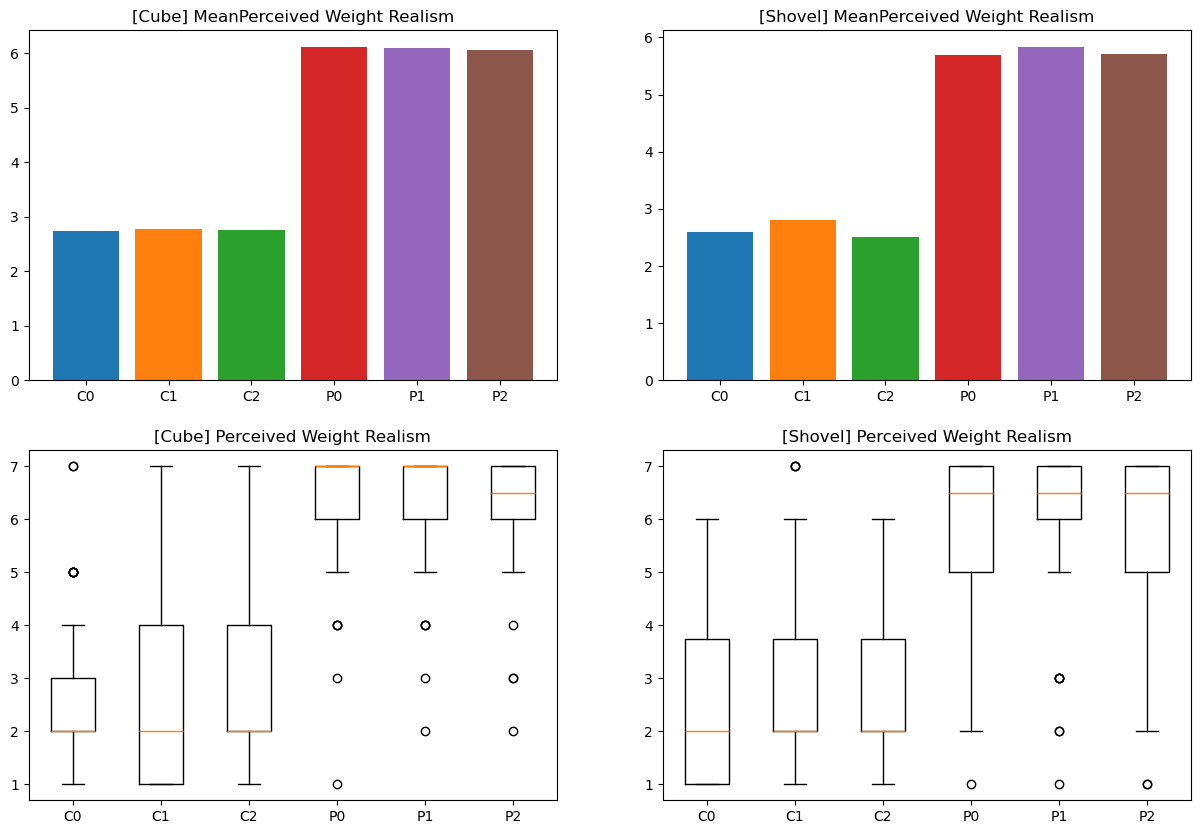

In [15]:
cube_values = list(map(lambda x: get_single(data, cube, x, general_weight_realism), conditions))
shovel_values = list(map(lambda x: get_single(data, shovel, x, general_weight_realism), conditions))

plot_experiments(
    cube_values= cube_values,
    shovel_values= shovel_values,
    title= 'Perceived Weight Realism',
    ylabel= ''
    )

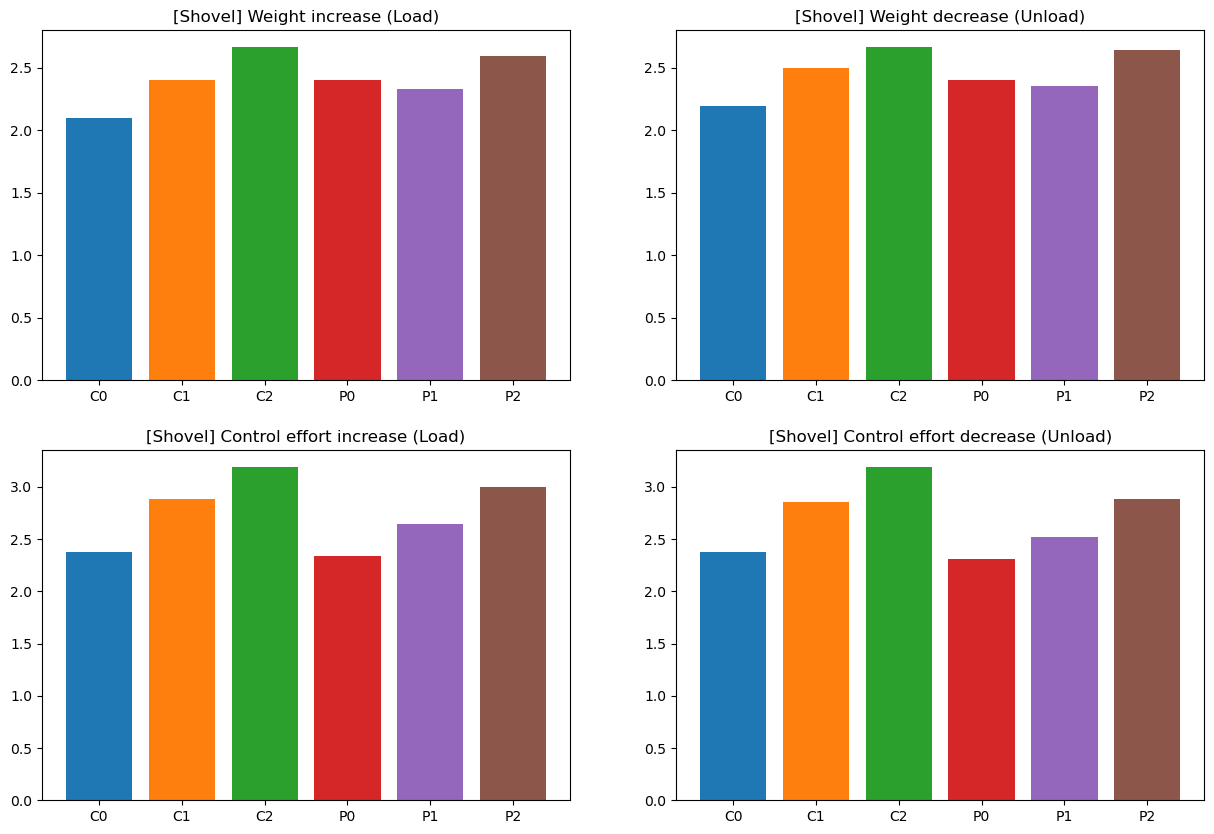

In [16]:
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

load_weight_values = list(map(lambda x: np.mean(get_single(data, shovel, x, shovel_load_weight)), conditions))
axs[0][0].bar(conditions, load_weight_values, color=colors)
axs[0][0].set_title('[Shovel] Weight increase (Load)')

unload_weight_values = list(map(lambda x: np.mean(get_single(data, shovel, x, shovel_unload_weight)), conditions))
axs[0][1].bar(conditions, unload_weight_values, color=colors)
axs[0][1].set_title('[Shovel] Weight decrease (Unload)')

load_effort_values = list(map(lambda x: np.mean(get_single(data, shovel, x, shovel_load_effort)), conditions))
axs[1][0].bar(conditions, load_effort_values, color=colors)
axs[1][0].set_title('[Shovel] Control effort increase (Load)')

unload_effort_values = list(map(lambda x: np.mean(get_single(data, shovel, x, shovel_unload_effort)), conditions))
axs[1][1].bar(conditions, unload_effort_values, color=colors)
axs[1][1].set_title('[Shovel] Control effort decrease (Unload)')

plt.show()